In [1]:
import sys
import os

# Get the project root (one directory above the notebook location)
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

from utils import *

In [2]:
# After running CT3 and getting 'summary'
root = "C:\\Users\\JanderM\\OneDrive - University of Twente\\Documents\\Github Repos\\WP3_eXplainable_and_Fair_AI\\IRP1\\Code\\ct3\\code\\results\\20251118-140903\\PredictionTask\\UCBBanditAgent\\LinearTrend"

# Example: plot directional accuracy vs μ
metrics =  load_ct3_metrics(root)
metrics

{'D_ham': {-0.5: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  -0.25: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.25: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.5: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]},
 'delta_p': {-0.5: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  -0.25: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.0: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.25: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
  0.5: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]},
 'p_up': {-0.5: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  -0.25: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  0.0: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  0.25: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
  0.5: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}}

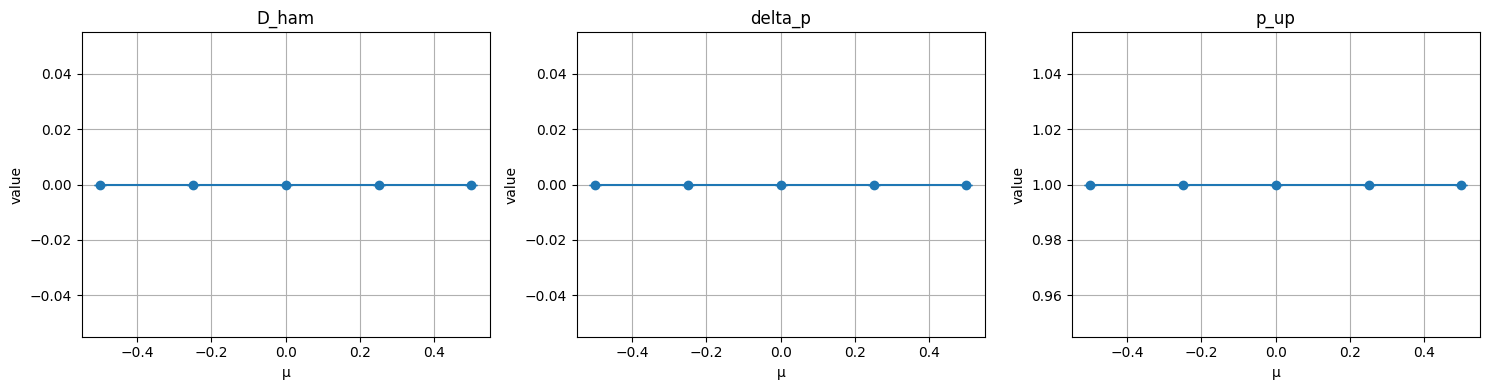

In [3]:
# --- Plot ---
num_metrics = len(metrics)
fig, axes = plt.subplots(1, num_metrics, figsize=(5 * num_metrics, 4), squeeze=False)
axes = axes[0]

for ax, (metric, mu_dict) in zip(axes, metrics.items()):
    mus = np.array(sorted(mu_dict.keys()))
    means = np.array([np.mean(mu_dict[mu]) for mu in mus])
    stds = np.array([np.std(mu_dict[mu]) for mu in mus])
    
    ax.errorbar(mus, means, yerr=stds, fmt='-o', capsize=4)
    ax.set_title(metric)
    ax.set_xlabel("μ")
    ax.set_ylabel("value")
    ax.grid(True)

plt.tight_layout()
plt.show()

In [4]:
train_log = load_training_log(root)

print(len(train_log),train_log[:3])

1000 [{'t': 1, 'value_prev': 0.0, 'value': 9.880821445482871, 'bet': 0, 'received_reward': -1, 'reward_cum': -1}, {'t': 2, 'value_prev': 9.880821445482871, 'value': 10.3444513937147, 'bet': 1, 'received_reward': 1, 'reward_cum': 0}, {'t': 3, 'value_prev': 10.3444513937147, 'value': 10.930567695218357, 'bet': 1, 'received_reward': 1, 'reward_cum': 1}]


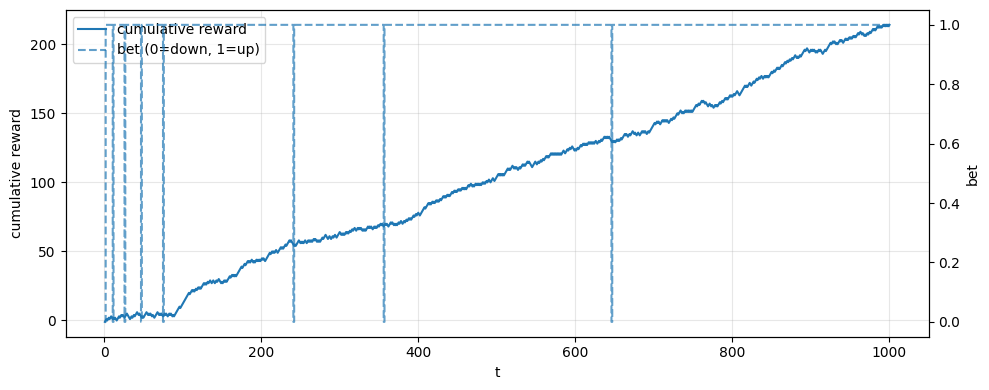

In [ ]:
plot_reward_and_bets(train_log)


We can see that agents upward actions (bets) and cumulative return align with the linear trend generator with positive drift. So the agent performs well on this functional form and parameter (treated as resulting in a fixed distribution) so it displays distributional learning ability. When looking at the CT3 plot we see that the policy is not sensitive to changes in the drift parameter. We predict that the task log of negative drift runs will show worse returns than the training log.

In [6]:
root = "../results/20251118-140903/PredictionTask/UCBBanditAgent/LinearTrend"
mu = -0.5

logs = load_task_logs_for_mu(root, mu)

for k, log in logs.items():
    print("k=", k, "entries:", len(log))


k= 0 entries: 1000
k= 1 entries: 1000
k= 2 entries: 1000
k= 3 entries: 1000
k= 4 entries: 1000
k= 5 entries: 1000
k= 6 entries: 1000
k= 7 entries: 1000


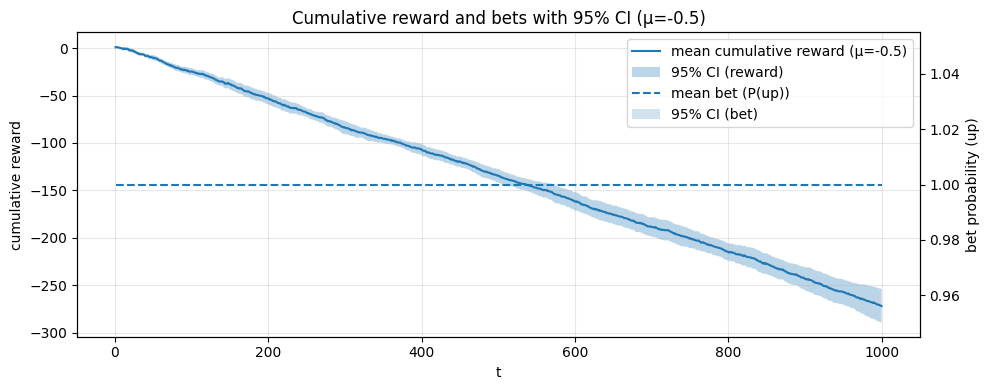

In [12]:
plot_reward_and_bets_with_ci_from_logs(logs, mu=-0.5)

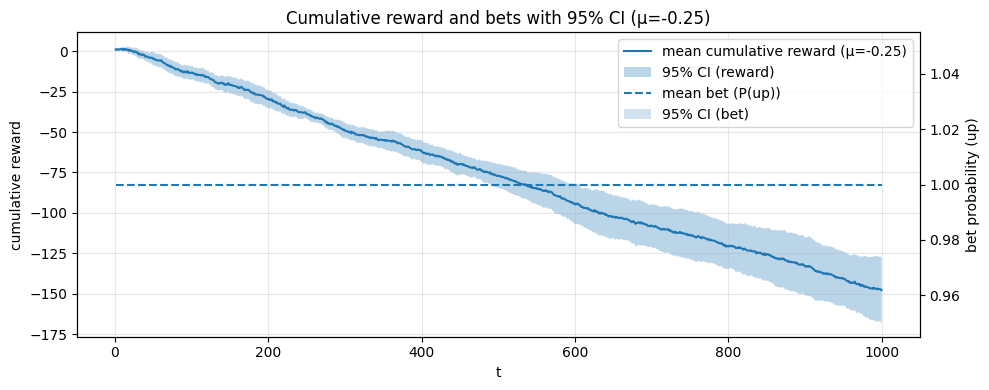

In [8]:
logs_by_k = load_task_logs_for_mu(root, mu=-0.25)
plot_reward_and_bets_with_ci_from_logs(logs_by_k, mu=-0.25)

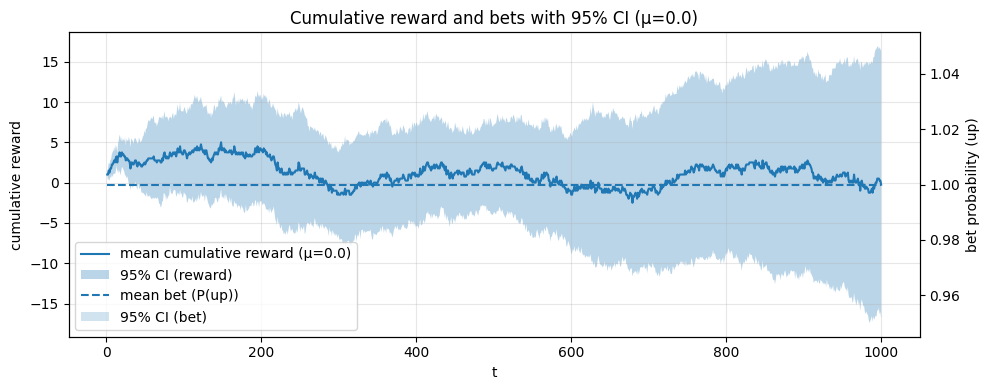

In [9]:
logs_by_k = load_task_logs_for_mu(root, mu=0.0)
plot_reward_and_bets_with_ci_from_logs(logs_by_k, mu=0.0)

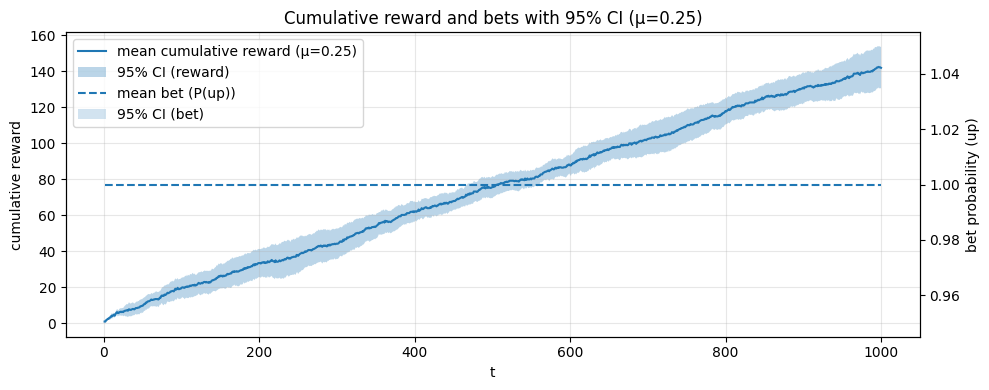

In [10]:
logs_by_k = load_task_logs_for_mu(root, mu=0.25)
plot_reward_and_bets_with_ci_from_logs(logs_by_k, mu=0.25)

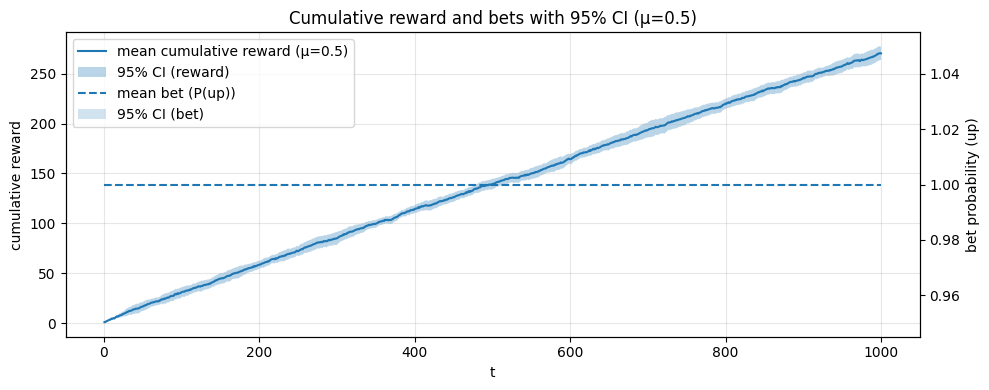

In [11]:
logs_by_k = load_task_logs_for_mu(root, mu=0.5)
plot_reward_and_bets_with_ci_from_logs(logs_by_k, mu=0.5)

We can see that cumulative reward for counterfactuals with negative drift is negative and hovering around mean for no drift (as there is no signal, just noise), while positive reward drift values (as during training phase) lead to positive cumulative rewards. This aligns with our prediction above. The trained policy seems to only have learned the distribution of actions (more likely to pick up than down) based on the generator's functional form and fixed parameter rather than learning the mechanistic relationship of the drift parameter and actions. This might be due to the UCBBanditAgent only looking at actions and lacking the ability to estimate parameters. Contextual bandits might allow to overcome this limitation if the context captures the drift parameter and maps its relationship to actions.


We are also able to show that in this case the CT3 metrics indicating no causal sensitivity to parameter variation predicts this policies inability to sustain cumulative reward under parameter variation.